In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

## **Import Module**

In [2]:
%%capture
!pip -q install torchinfo

# **실습 : DCGAN with MNIST**

## **Import Module**

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from torchvision.transforms import v2

#from torchmetrics import functional as FM
from torchinfo import summary
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

torch.__version__
device='cuda:0'

In [ ]:
# (Google Drive 연결 셀 제거 — 저장 경로는 /content/models/PT/ 로 바꿨다)
# # gdriver mount to load saved model


## **DataSet**

### Load

In [5]:
from torchvision.datasets import FashionMNIST, MNIST

class Normalize:
    def __call__(self, sample):
        sample = np.array(sample)
        image = (sample - 127.5) / 127.5
        return torch.FloatTensor(image).unsqueeze(dim=0)

# Normalize data to [-1 ~ 1]
transform = v2.Compose([Normalize(),])

# download path 정의
download_root = './MNIST_DATASET'
train_dataset = MNIST(download_root, transform=transform, train=True, download=True)
test_dataset = MNIST(download_root, transform=transform, train=False, download=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


### Preprocessing

## **Model**

### Function define for saving model

In [6]:
save_path='/content/models/PT/'
os.makedirs(save_path, exist_ok=True)

In [7]:
def save_models(title, epoch):
    torch.save(generator, save_path+"dcgan_generator_{}_{}.pt".format(title, epoch))
    torch.save(discriminator, save_path+"dcgan_discriminator_{}_{}.pt".format(title, epoch))

def load_models(title, epoch):
    gen = torch.load(save_path+"dcgan_generator_{}_{}.pt".format(title, epoch))
    dis = torch.load(save_path+"dcgan_discriminator_{}_{}.pt".format(title, epoch))
    return gen, dis

In [8]:
train_model = True      # T: training
#train_model = False     # F: loading

### model params

In [9]:
latent_dim = 100
height = 28
width = 28
channels = 1

### Define generator

In [10]:
# Generator model
class Generator(nn.Module):
    def __init__(self, latent_dim, channels):
        super(Generator, self).__init__()
        self.generator = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.Unflatten(1, (128, 7, 7)),
            nn.BatchNorm2d(128,momentum=0.8),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 128, 5, 2,
                               padding=2, output_padding=1),
            nn.BatchNorm2d(128,momentum=0.8),  #(128,14,14)
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, 5, 2,
                               padding=2, output_padding=1),
            nn.BatchNorm2d(64,momentum=0.8),   #(64,28,28)
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, 5, 1, padding=2),
            nn.BatchNorm2d(32,momentum=0.8),   #(32,28,28)
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, channels, 5, padding=2),
            nn.Tanh()             #(1,28,28)
        )

    def forward(self, x):
        out = self.generator(x)
        return out

generator = Generator(latent_dim, channels).to(device)
summary(generator, input_size=(8, 100))

Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [8, 1, 28, 28]            --
├─Sequential: 1-1                        [8, 1, 28, 28]            --
│    └─Linear: 2-1                       [8, 6272]                 633,472
│    └─Unflatten: 2-2                    [8, 128, 7, 7]            --
│    └─BatchNorm2d: 2-3                  [8, 128, 7, 7]            256
│    └─LeakyReLU: 2-4                    [8, 128, 7, 7]            --
│    └─ConvTranspose2d: 2-5              [8, 128, 14, 14]          409,728
│    └─BatchNorm2d: 2-6                  [8, 128, 14, 14]          256
│    └─LeakyReLU: 2-7                    [8, 128, 14, 14]          --
│    └─ConvTranspose2d: 2-8              [8, 64, 28, 28]           204,864
│    └─BatchNorm2d: 2-9                  [8, 64, 28, 28]           128
│    └─LeakyReLU: 2-10                   [8, 64, 28, 28]           --
│    └─ConvTranspose2d: 2-11             [8, 32, 28, 28]           

### Define discriminator

In [11]:
# Discriminator model
class Discriminator(nn.Module):
    def __init__(self, channels):
        super(Discriminator, self).__init__()
        self.discriminator = nn.Sequential(
#            nn.LeakyReLU(0.2), ##
            nn.Conv2d(channels, 32, 5, 2, padding=2),
            nn.LeakyReLU(0.2), nn.Dropout(0.25),
            nn.Conv2d(32, 64, 5, 2, padding=2),
            nn.LeakyReLU(0.2), nn.Dropout(0.25),
            nn.Conv2d(64, 128, 5, 2, padding=2),
            nn.LeakyReLU(0.2), nn.Dropout(0.25),
            nn.Conv2d(128, 256, 5, 1, padding=2),
            nn.Flatten(),
            nn.Linear(256*4*4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        out = self.discriminator(x)
        return out

discriminator = Discriminator(channels).to(device)
summary(discriminator, input_size=(8, channels, height, width))

Layer (type:depth-idx)                   Output Shape              Param #
Discriminator                            [8, 1]                    --
├─Sequential: 1-1                        [8, 1]                    --
│    └─Conv2d: 2-1                       [8, 32, 14, 14]           832
│    └─LeakyReLU: 2-2                    [8, 32, 14, 14]           --
│    └─Dropout: 2-3                      [8, 32, 14, 14]           --
│    └─Conv2d: 2-4                       [8, 64, 7, 7]             51,264
│    └─LeakyReLU: 2-5                    [8, 64, 7, 7]             --
│    └─Dropout: 2-6                      [8, 64, 7, 7]             --
│    └─Conv2d: 2-7                       [8, 128, 4, 4]            204,928
│    └─LeakyReLU: 2-8                    [8, 128, 4, 4]            --
│    └─Dropout: 2-9                      [8, 128, 4, 4]            --
│    └─Conv2d: 2-10                      [8, 256, 4, 4]            819,456
│    └─Flatten: 2-11                     [8, 4096]                 --


In [ ]:
#torch.onnx.export(discriminator, torch.zeros((8, channels, height, width)).to(device), '4.4_dcgan_discriminator.onnx')

### Fit function

In [12]:
batch_size = 600
num_epochs = 10
print_step=100
lr = 0.0001

In [13]:
generator = Generator(latent_dim, channels).to(device)
discriminator = Discriminator(channels).to(device)
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_g = torch.optim.Adam(generator.parameters(), lr=lr)

In [15]:
def show_images(generated_images, n=4, m=8, figsize=(8, 4)):
    fig = plt.figure(figsize=figsize)
    plt.subplots_adjust(top=1, bottom=0, hspace=0, wspace=0.05)
    for i in range(n):
        for j in range(m):
            k = i * m + j
            ax = fig.add_subplot(n, m, i * m + j + 1)
            ax.imshow(generated_images[k][0, :, :])#, cmap=plt.cm.bone)
            ax.grid(False)
            ax.xaxis.set_ticks([])
            ax.yaxis.set_ticks([])
    plt.tight_layout()
    plt.show()

In [ ]:
noise_data = torch.randn((batch_size, latent_dim))
show_images(0.5 * generator(noise_data.to(device)).cpu().detach().numpy() + 0.5) #Generator Af='tanh'

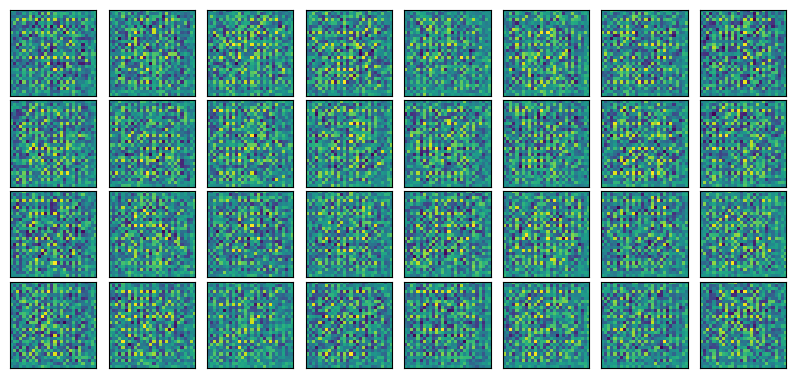

In [17]:
def train(num_epochs, print_every):
    for epoch in range(num_epochs):
        idx = np.random.randint(0, len(train_dataset), batch_size)
        r_samples = torch.cat([train_dataset[i][0].unsqueeze(dim=0) for i in idx])
        # Data for training the discriminator
        r_labels = torch.ones((batch_size, 1))
        latent_samples = torch.randn((batch_size, latent_dim))
        f_samples = generator(latent_samples.to(device))
        f_labels = torch.zeros((batch_size, 1))
        all_samples = torch.cat((r_samples.to(device), f_samples))
        all_labels = torch.cat((r_labels, f_labels))
        # Training the discriminator
        discriminator.zero_grad()
        output_d = discriminator(all_samples.to(device))
        loss_d = F.binary_cross_entropy(output_d, all_labels.to(device))
        loss_d.backward()
        optimizer_d.step()

        # Data for training the generator
        latent_samples = torch.randn((batch_size, latent_dim))
        # Training the generator
        generator.zero_grad()
        f_samples = generator(latent_samples.to(device))
        output_d = discriminator(f_samples.to(device))
        loss_g = F.binary_cross_entropy(output_d, r_labels.to(device))
        loss_g.backward()
        optimizer_g.step()

        # Show loss
        if epoch % print_every == 0:
            print(f"Epoch: {epoch} Loss D.: {loss_d}")
            print(f"Epoch: {epoch} Loss G.: {loss_g}")

### Fit 500

In [18]:
%%time
if train_model == True:
    history500 = train(500, 10)
    save_models("mnist", 500)
else:
    generator, _, _ = load_models("mnist",500)

# Wall time: 1min 7s

Epoch: 0 Loss D.: 0.6955640316009521
Epoch: 0 Loss G.: 0.68511563539505
Epoch: 10 Loss D.: 0.5741562247276306
Epoch: 10 Loss G.: 0.6300453543663025
Epoch: 20 Loss D.: 0.4009009003639221
Epoch: 20 Loss G.: 1.1215673685073853
Epoch: 30 Loss D.: 0.2639959156513214
Epoch: 30 Loss G.: 1.3954575061798096
Epoch: 40 Loss D.: 0.22911851108074188
Epoch: 40 Loss G.: 2.788287878036499
Epoch: 50 Loss D.: 0.14796893298625946
Epoch: 50 Loss G.: 3.391286849975586
Epoch: 60 Loss D.: 0.2205398678779602
Epoch: 60 Loss G.: 3.1942529678344727
Epoch: 70 Loss D.: 0.3362114429473877
Epoch: 70 Loss G.: 2.256146192550659
Epoch: 80 Loss D.: 0.021304475143551826
Epoch: 80 Loss G.: 4.157475471496582
Epoch: 90 Loss D.: 0.05576428771018982
Epoch: 90 Loss G.: 3.2760889530181885
Epoch: 100 Loss D.: 0.09878158569335938
Epoch: 100 Loss G.: 3.0179593563079834
Epoch: 110 Loss D.: 1.078198790550232
Epoch: 110 Loss G.: 0.8323649168014526
Epoch: 120 Loss D.: 0.21451793611049652
Epoch: 120 Loss G.: 3.008897066116333
Epoch: 13

>#### Plot 500

In [ ]:
noise_data = torch.randn((batch_size, latent_dim))
show_images(0.5 * generator(noise_data.to(device)).cpu().detach().numpy() + 0.5) #Generator Af='tanh'

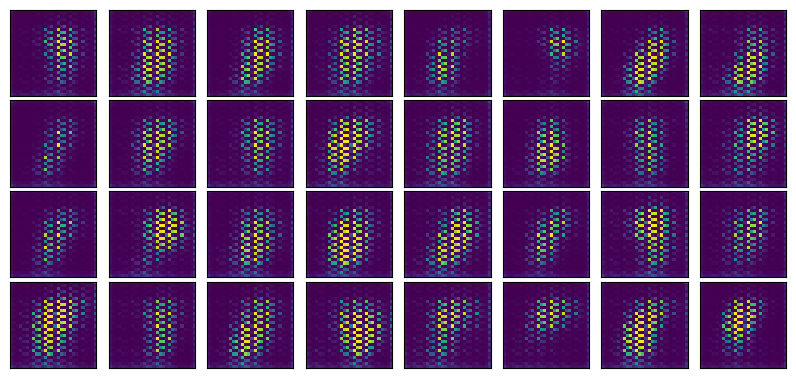

### Fit   +4500

In [ ]:
train_model = True

In [ ]:
%%time
if train_model == True:
    history500 = train(4500, 100)
    save_models("mnist", 5000)
else:
    generator, _, _ = load_models("mnist", 5000)

# Wall time: 27min 14s
# A100: Wall time: 7min 34s

Epoch: 0 Loss D.: 0.3402971625328064
Epoch: 0 Loss G.: 1.6922383308410645
Epoch: 100 Loss D.: 0.0135074807330966
Epoch: 100 Loss G.: 5.390251636505127
Epoch: 200 Loss D.: 0.004628857597708702
Epoch: 200 Loss G.: 6.9189324378967285
Epoch: 300 Loss D.: 0.0016741681611165404
Epoch: 300 Loss G.: 7.678911209106445
Epoch: 400 Loss D.: 0.0011055469512939453
Epoch: 400 Loss G.: 8.068119049072266
Epoch: 500 Loss D.: 0.10956160724163055
Epoch: 500 Loss G.: 7.816456317901611
Epoch: 600 Loss D.: 0.3697212338447571
Epoch: 600 Loss G.: 1.995063304901123
Epoch: 700 Loss D.: 0.4358111023902893
Epoch: 700 Loss G.: 2.6211917400360107
Epoch: 800 Loss D.: 0.025619221851229668
Epoch: 800 Loss G.: 5.3021039962768555
Epoch: 900 Loss D.: 0.4014410674571991
Epoch: 900 Loss G.: 2.7119181156158447
Epoch: 1000 Loss D.: 0.1459852159023285
Epoch: 1000 Loss G.: 4.4939680099487305
Epoch: 1100 Loss D.: 0.27652257680892944
Epoch: 1100 Loss G.: 3.1612699031829834
Epoch: 1200 Loss D.: 0.37804514169692993
Epoch: 1200 Loss

>#### Plot 5000

In [ ]:
noise_data = torch.randn((batch_size, latent_dim))
show_images(0.5 * generator(noise_data.to(device)).cpu().detach().numpy() + 0.5) #Generator Af='tanh'

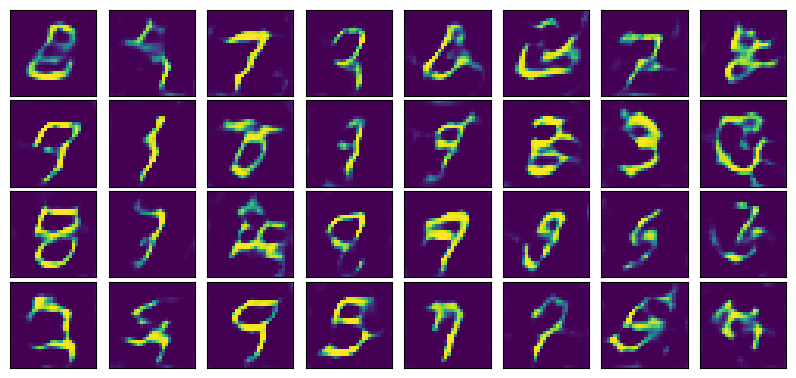

### Fit +15000

In [ ]:
%%time
if train_model == True:
    train(15000, 100)
    save_models("mnist", 20000)
else:
    generator, _, _ = load_models("mnist", 20000)

# Wall time: 1h 31min 19s
# A100:Wall time: 25min 18s

Epoch: 0 Loss D.: 0.28866100311279297
Epoch: 0 Loss G.: 2.4133803844451904
Epoch: 100 Loss D.: 0.25901955366134644
Epoch: 100 Loss G.: 2.457676649093628
Epoch: 200 Loss D.: 0.295992374420166
Epoch: 200 Loss G.: 2.036501884460449
Epoch: 300 Loss D.: 0.35470110177993774
Epoch: 300 Loss G.: 2.4231314659118652
Epoch: 400 Loss D.: 0.2852194309234619
Epoch: 400 Loss G.: 2.9196677207946777
Epoch: 500 Loss D.: 0.31463271379470825
Epoch: 500 Loss G.: 2.5353336334228516
Epoch: 600 Loss D.: 0.4466186761856079
Epoch: 600 Loss G.: 2.4339165687561035
Epoch: 700 Loss D.: 0.3454316258430481
Epoch: 700 Loss G.: 2.093691110610962
Epoch: 800 Loss D.: 0.33617088198661804
Epoch: 800 Loss G.: 2.5068254470825195
Epoch: 900 Loss D.: 0.30151450634002686
Epoch: 900 Loss G.: 2.715001344680786
Epoch: 1000 Loss D.: 0.35051068663597107
Epoch: 1000 Loss G.: 2.6176164150238037
Epoch: 1100 Loss D.: 0.3116821348667145
Epoch: 1100 Loss G.: 2.496413230895996
Epoch: 1200 Loss D.: 0.36162811517715454
Epoch: 1200 Loss G.: 2

>#### Plot 20000

In [ ]:
noise_data = torch.randn((batch_size, latent_dim))
show_images(0.5 * generator(noise_data.to(device)).cpu().detach().numpy() + 0.5) #Generator Af='tanh'

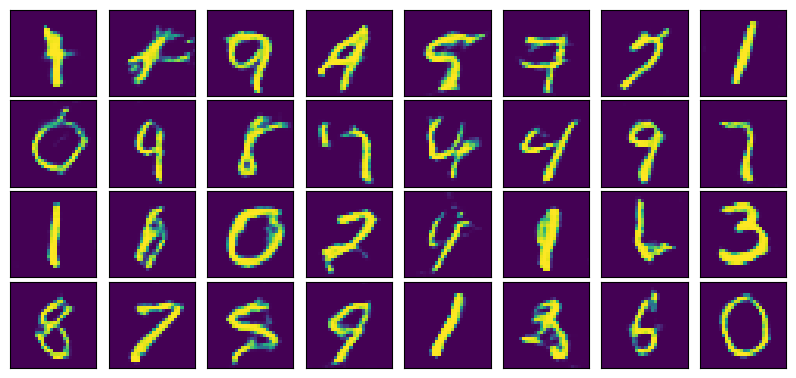

## **DCGAN Model load**

## Load model

### load dc gan mnist and show the result

In [ ]:
latent_dim = 100

In [ ]:
def show_images(generated_images, n=4, m=8, figsize=(9, 5)):
    fig = plt.figure(figsize=figsize)
    plt.subplots_adjust(top=1, bottom=0, hspace=0, wspace=0.05)
    for i in range(n):
        for j in range(m):
            k = i * m + j
            ax = fig.add_subplot(n, m, i * m + j + 1)
            ax.imshow(generated_images[k][0, :, :])#, cmap=plt.cm.bone)
            ax.grid(False)
            ax.xaxis.set_ticks([])
            ax.yaxis.set_ticks([])
    plt.tight_layout()
    plt.show()

In [ ]:
generator = torch.load(save_path+"dcgan_generator_mnist_20000.pt")

<ipython-input-27-da2ec0b8d2cf>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator = torch.load(save_path+"dcgan_generator_mnist_20000.pt")


In [ ]:
noise_data = torch.randn((batch_size, latent_dim))
show_images(0.5 * generator(noise_data.to(device)).cpu().detach().numpy() + 0.5)

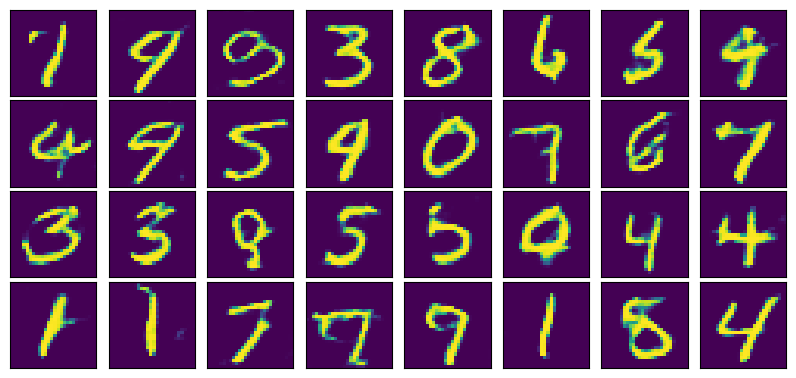